# Effect of sample size on gene-gene correlation significance

For the `gene_1`-`gene_2` pair at `time_step == 1`, subsample the 12k simulated cells down to 6000 / 5000 / 4000 cells (100 replicates each), and for every replicate:
- compute the observed Spearman correlation,
- build a 10,000-shuffle rank-permutation null distribution (same approach as `check_gene_gene_correlation_threshold` in `correlation_analysis_functions.py`),
- get the empirical p-value of the observed correlation against that null,
- get the |correlation| threshold needed for significance,
- get the variance of the 10k null-shuffle correlations.

In [64]:
import sys, os
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import numba

In [65]:
numba.config.THREADING_LAYER = "workqueue" 

In [66]:
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/TwINFER/code/TwINFER"


In [67]:
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/TwINFER/code/TwINFER"
sys.path.append(path_to_code_repo)

from TwINFER_function_scripts.correlation_analysis_functions import (
    _rank_center_and_sumsq,
    _rank_permutation_null_kernel,
    _spawn_independent_seeds,
)

In [58]:
# ---- Config ----
SIM_FILE = f"/home/gzu5140/Keerthana_b1042/TwINFER/simulation_data/figure_2/A_B/df_rows_0_1_08082025_093223_ncells_6000_A_B_rep_0.csv"
TIME_STEP = 1  # "t1"
GENE_1, GENE_2 = "gene_1", "gene_2"
SAMPLE_SIZES = [6000, 4000, 2000, 1000, 500]
N_REPS = 100
N_SHUFFLES = 10_000
P_VAL_THRESHOLD = 0.01
BASE_SEED = 101010
N_CORES_TO_USE = 4

numba.set_num_threads(max(1, N_CORES_TO_USE))

In [61]:
# ---- Load simulation, restrict to a single time point ----
df = pd.read_csv(SIM_FILE)
df_t1 = df[df["time_step"] == TIME_STEP].reset_index(drop=True)
print(f"Cells available at time_step={TIME_STEP}: {len(df_t1)}")

x_full = df_t1[f"{GENE_1}_mRNA"].to_numpy(dtype=np.float64)
y_full = df_t1[f"{GENE_2}_mRNA"].to_numpy(dtype=np.float64)
n_total_cells = len(x_full)

Cells available at time_step=1: 12000


In [68]:
def null_distribution_for_pair(x, y, n_shuffles, seed):
    """
    Rank-permutation null distribution of the Spearman correlation between x and y:
    ranks of x stay fixed, ranks of y are randomly permuted `n_shuffles` times.
    Reuses the same numba kernel as check_gene_gene_correlation_threshold.
    """
    gene_matrix = np.vstack([x, y])  # shape (2, n_cells)
    Rc, s2 = _rank_center_and_sumsq(gene_matrix)
    denom = np.sqrt(np.outer(s2, s2))
    denom[denom == 0] = np.nan

    seeds = _spawn_independent_seeds(seed, n_shuffles)
    pair_i = np.array([0], dtype=np.int64)
    pair_j = np.array([1], dtype=np.int64)

    null_matrix = _rank_permutation_null_kernel(Rc, Rc, denom, seeds, pair_i, pair_j)
    return null_matrix[:, 0]

In [69]:
records = []
rng = np.random.default_rng(BASE_SEED)

for n_sample in SAMPLE_SIZES:
    for rep in tqdm(range(N_REPS), desc=f"n_sample={n_sample}"):
        # subsample cells without replacement
        idx = rng.choice(n_total_cells, size=n_sample, replace=False)
        x = x_full[idx]
        y = y_full[idx]

        # observed correlation for this subsample
        obs_corr = spearmanr(x, y).correlation

        # 10k-shuffle null distribution for this specific subsample
        shuffle_seed = BASE_SEED + n_sample * 100_000 + rep
        null_corrs = null_distribution_for_pair(x, y, N_SHUFFLES, shuffle_seed)

        # two-sided empirical p-value of the observed correlation against its null
        p_plus = np.mean(null_corrs >= obs_corr)
        p_minus = np.mean(null_corrs <= obs_corr)
        p_value = min(2 * p_plus, 2 * p_minus, 1.0)

        # |correlation| threshold that would be required for significance at P_VAL_THRESHOLD
        sig_threshold = np.nanpercentile(np.abs(null_corrs), 100 * (1 - P_VAL_THRESHOLD / 2))

        records.append({
            "sample_size": n_sample,
            "rep": rep,
            "observed_correlation": obs_corr,
            "p_value": p_value,
            "significant": p_value < P_VAL_THRESHOLD,
            "null_corr_threshold": sig_threshold,
            "null_corr_variance": np.nanvar(null_corrs),
        })

results_df_neg = pd.DataFrame(records)
results_df_neg.to_csv(f"{path_to_code_repo}/additional_analysis/sample_size_correlation_results_A_B.csv", index=False)
results_df_neg.head()

n_sample=6000:   0%|          | 0/100 [00:00<?, ?it/s]

n_sample=4000:   0%|          | 0/100 [00:00<?, ?it/s]

n_sample=2000:   0%|          | 0/100 [00:00<?, ?it/s]

n_sample=1000:   0%|          | 0/100 [00:00<?, ?it/s]

n_sample=500:   0%|          | 0/100 [00:00<?, ?it/s]

,sample_size,rep,observed_correlation,p_value,significant,null_corr_threshold,null_corr_variance
0,6000,0,0.002011,0.8702,False,0.036453,0.000168
1,6000,1,0.005305,0.6770,False,0.035636,0.000165
2,6000,2,0.003921,0.7798,False,0.035746,0.000169
3,6000,3,0.001887,0.8978,False,0.035121,0.000164
4,6000,4,0.017225,0.1844,False,0.035793,0.000166


In [70]:
del records
import gc
gc.collect()

23

In [4]:
results_df = pd.read_csv(f"{path_to_code_repo}/additional_analysis/sample_size_correlation_results.csv")


In [71]:
results_df_neg

,sample_size,rep,observed_correlation,p_value,significant,null_corr_threshold,null_corr_variance
0,6000,0,0.002011,0.8702,False,0.036453,0.000168
1,6000,1,0.005305,0.6770,False,0.035636,0.000165
2,6000,2,0.003921,0.7798,False,0.035746,0.000169
3,6000,3,0.001887,0.8978,False,0.035121,0.000164
4,6000,4,0.017225,0.1844,False,0.035793,0.000166
...,...,...,...,...,...,...,...
495,500,95,0.094832,0.0352,False,0.127694,0.002037
496,500,96,-0.025848,0.5626,False,0.125404,0.002051
497,500,97,0.033030,0.4450,False,0.125809,0.002000
498,500,98,0.098847,0.0252,False,0.122372,0.001971


In [ ]:
thres_calib = 0.0235
n_calib = 11999

c = thres_calib*np.sqrt(n_calib)
# T = rho * sqrt(n_cells - 1) # standardized at the analysis n
results_df_neg['standardized_observed_correlation'] = results_df_neg['observed_correlation']*np.sqrt(results_df_neg['sample_size'] - 1)
results_df_neg['new_significant'] = results_df_neg['standardized_observed_correlation'].abs() > c

In [ ]:
# correction: compare the standardized statistic to a fixed critical value c
# c = rho_cal * sqrt(n_cal - 1) # stored once from calibration
# T = rho * sqrt(n_cells - 1) # standardized at the analysis n
# flag if abs(T) > c # equivalently abs(rho) > c / sqrt(n_cells - 1)

In [ ]:
results_df['standardized_corr_threshold'].unique()

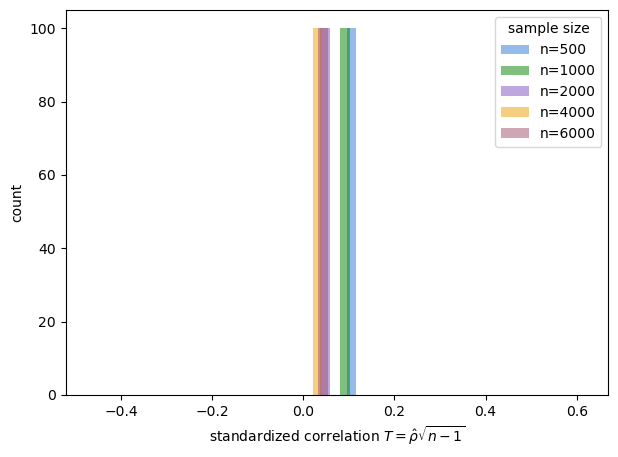

In [54]:
import matplotlib.pyplot as plt

# fixed categorical order (validated for colorblind-safety) -- do not reorder or cycle
CATEGORICAL_COLORS = ["#2a78d6", "#008300", "#7e4fc1", "#eda100", "#a0516b"]  # blue, green, magenta, yellow, purple

sample_sizes_sorted = sorted(results_df["sample_size"].unique())
if len(sample_sizes_sorted) > len(CATEGORICAL_COLORS):
    raise ValueError(f"Add more colors: {len(sample_sizes_sorted)} sample sizes but only {len(CATEGORICAL_COLORS)} colors defined")

fig, ax = plt.subplots(figsize=(7, 5))
for n_sample, color in zip(sample_sizes_sorted, CATEGORICAL_COLORS):
    subset = results_df.loc[results_df["sample_size"] == n_sample, "standard_corr"]
    ax.hist(subset, bins=50, alpha=0.5, color=color, label=f"n={n_sample}")

ax.set_xlabel(r"standardized correlation $T = \hat{\rho}\sqrt{n-1}$")
ax.set_ylabel("count")
ax.legend(title="sample size")
plt.show()

In [49]:
c

np.float64(2.5741887557053773)

In [81]:
# ---- Summary across the 100 replicates, per sample size ----
summary = results_df_neg.groupby("sample_size").agg(
    mean_observed_correlation=("observed_correlation", "mean"),
    std_observed_correlation=("observed_correlation", "std"),
    mean_p_value=("p_value", "mean"),
    frac_significant=("significant", "mean"),
    standardized_observed_correlation=("standardized_observed_correlation", "mean"),
    frac_new_significant=("new_significant", "mean"),
    mean_null_corr_threshold=("null_corr_threshold", "mean"),
    mean_null_corr_variance=("null_corr_variance", "mean"),
    std_null_corr_variance=("null_corr_variance", "std"),
).reset_index().sort_values("sample_size", ascending=False)
summary

,sample_size,mean_observed_correlation,std_observed_correlation,mean_p_value,frac_significant,standardized_observed_correlation,frac_new_significant,mean_null_corr_threshold,mean_null_corr_variance,std_null_corr_variance
4,6000,0.010023,0.009133,0.455048,0.00,0.776303,0.07,0.036133,0.000167,0.000002
3,4000,0.012494,0.012156,0.465850,0.02,0.790102,0.16,0.044270,0.000250,0.000004
2,2000,0.010485,0.015762,0.544124,0.00,0.468776,0.18,0.062691,0.000500,0.000007
1,1000,0.010365,0.029398,0.541162,0.01,0.327615,0.39,0.088452,0.001000,0.000016
0,500,0.010397,0.046969,0.474110,0.01,0.232248,0.67,0.125550,0.002006,0.000028
